In [1]:
#import data manipulation libraries
import numpy as np
import pandas as pd

#import data visualziation libraries
import matplotlib.pyplot as plt
import seaborn as sns

#import logging 
import logging
logging.basicConfig(filename='model.log',
                    level=logging.INFO,
                    filemode='w',
                      format='%(asctime)s:%(levelname)s:%(message)s',
                      force=True)

import warnings
warnings.filterwarnings('ignore')

In [2]:
#data import using pandas function
url="https://raw.githubusercontent.com/Frisk516/Restaurant_revenue_MLModel/refs/heads/main/Restaurant_revenue%20(1).csv"
df=pd.read_csv(url,sep=',')
#shuffle the dataset
df.sample(frac=1)

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
907,31,28.995462,5.084628,Japanese,13.184203,0,2,109.676779
888,76,17.612995,18.617747,Japanese,42.687642,0,88,410.645005
375,45,18.652961,10.403810,American,35.330528,1,56,197.327537
842,57,15.988159,5.850302,Mexican,38.360060,0,67,302.419478
36,71,41.142878,2.984756,American,20.144511,1,47,309.359096
...,...,...,...,...,...,...,...,...
741,74,49.733477,17.051156,Italian,24.774165,0,33,491.812446
860,11,37.033650,12.741817,Japanese,47.505591,0,96,223.472425
779,60,31.064952,1.189431,American,44.960547,1,93,250.434718
629,72,33.908943,14.819625,American,44.742281,1,22,371.259293


In [3]:
logging.info("Data imported successfully")

In [4]:
#separating numerical and categorical data
numerical_data=df.select_dtypes(exclude=object)
categorial_data=df.select_dtypes(include=object)

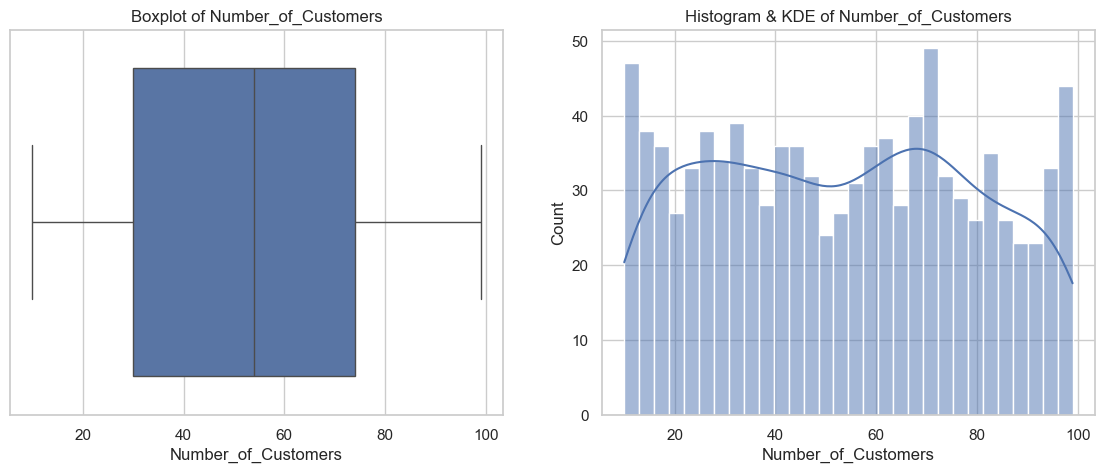

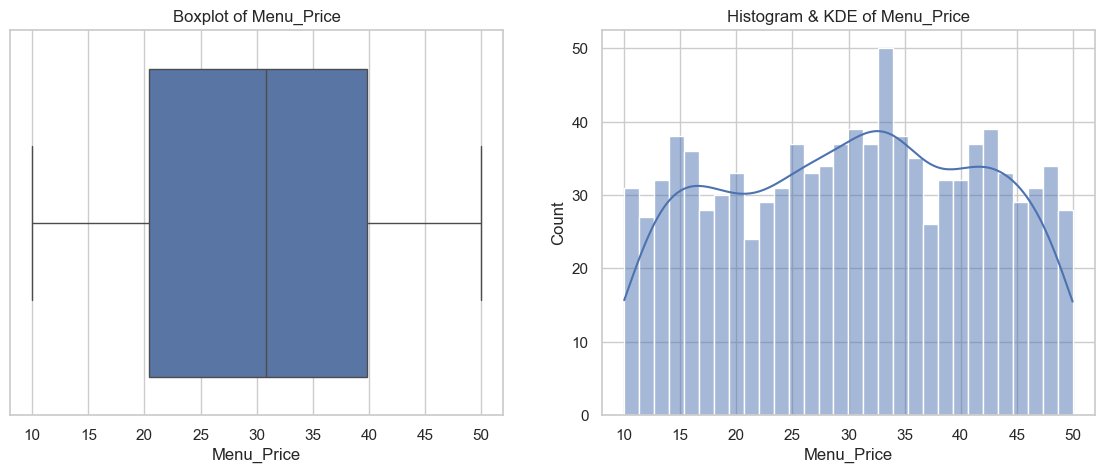

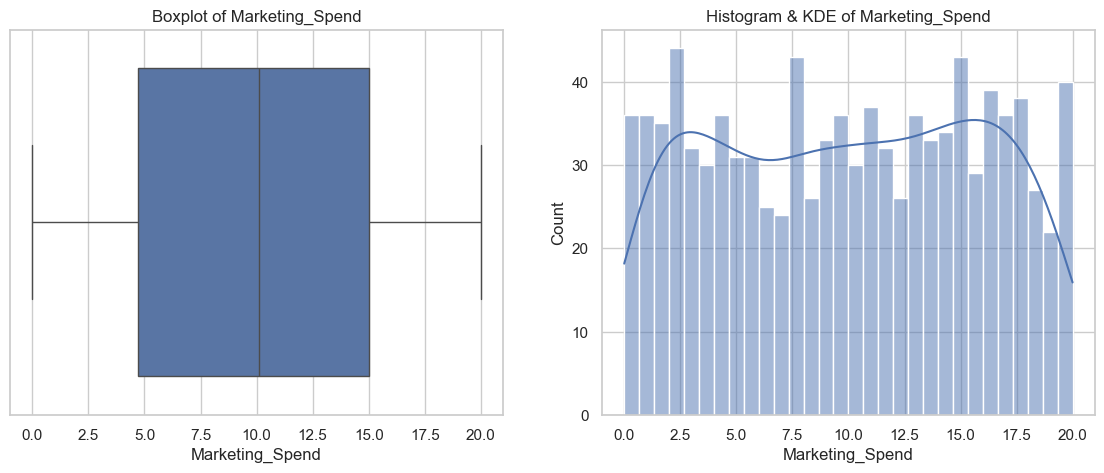

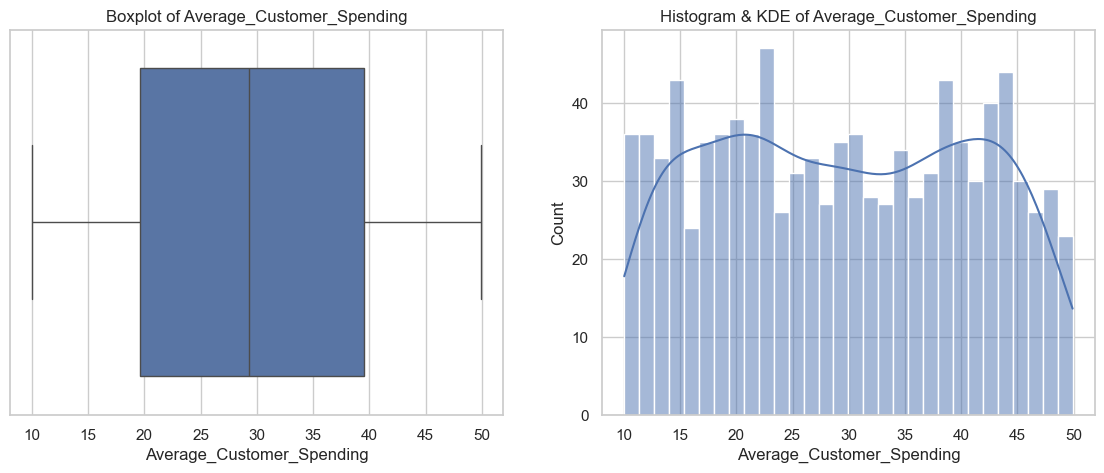

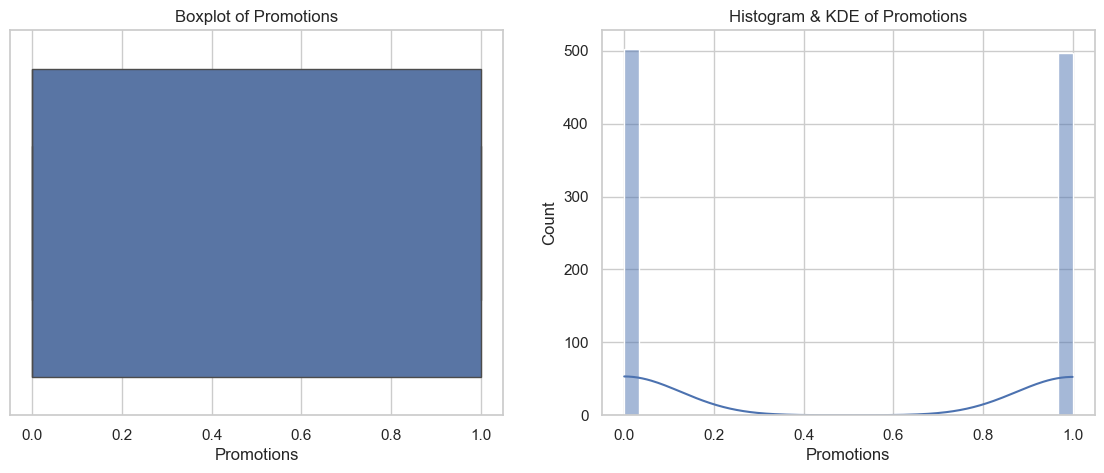

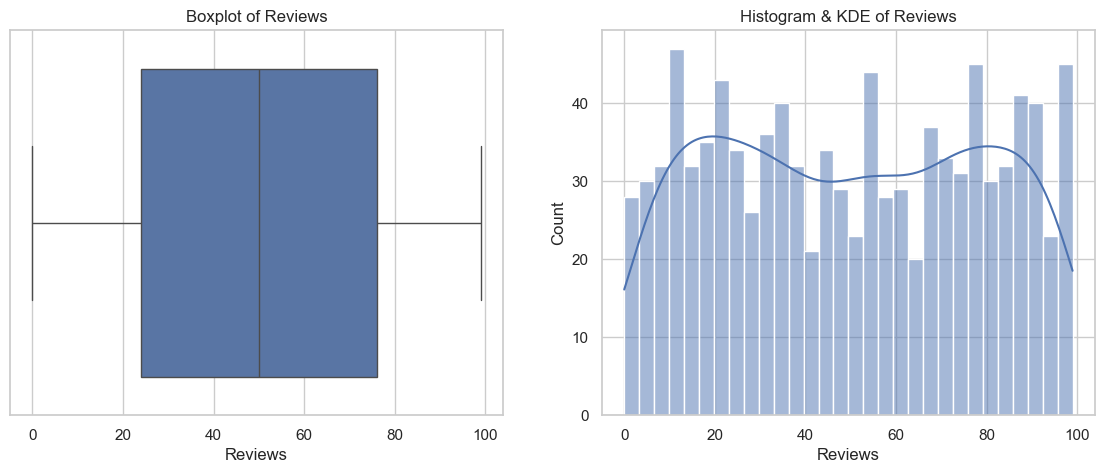

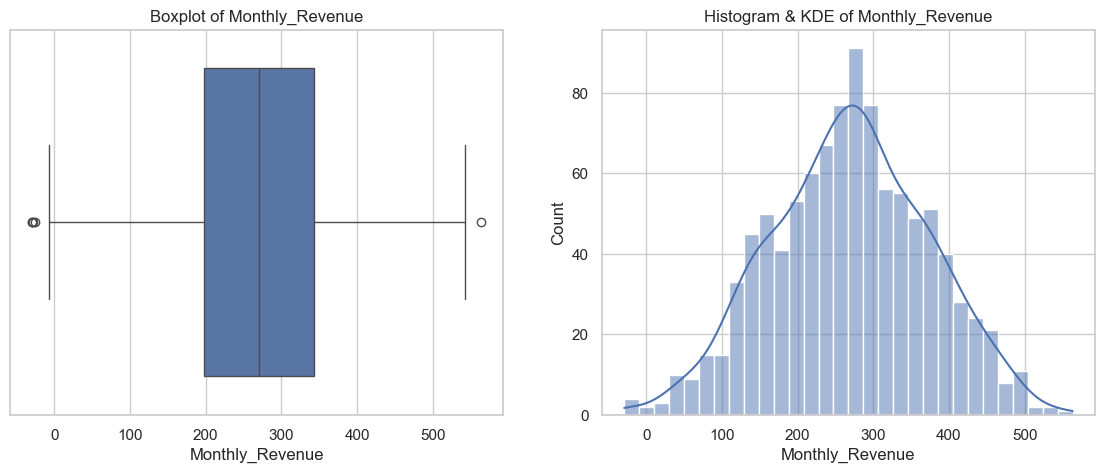

In [5]:
# Set plot style
sns.set(style="whitegrid")

# Plot boxplots and bell curves for each numerical feature
for col in numerical_data.columns:
    plt.figure(figsize=(14, 5))
    
    # Boxplot (shows outliers as points beyond whiskers)
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    
    # Bell curve: histogram + KDE (to check distribution shape)
    plt.subplot(1, 2, 2)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram & KDE of {col}')
    
    plt.show()

In [6]:
#performing EDA

from collections import OrderedDict
stats=[]
for i in numerical_data:
    numerical_stats=OrderedDict({
        'feature':i,
        'mean':df[i].mean(),
        'median':df[i].median(),
        'mode':df[i].mode()[0],
        'std':df[i].std(),
        'min':df[i].min(),
        'max':df[i].max(),
        'skewness':df[i].skew(),
        'kurtosis':df[i].kurt()
    })
    stats.append(numerical_stats)
    report=pd.DataFrame(stats)


# Outlier Identification :
outlier_label = []
for col in report['feature']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LW = Q1 - 1.5 * IQR   # LW : Lower Whisker Line
    UW = Q3 + 1.5 * IQR   # UW : Upper Whisker Line
    outliers = df[(df[col] < LW) | (df[col] > UW)]
    if not outliers.empty:
        outlier_label.append("Has Outliers")
    else:
        outlier_label.append("No Outliers")

report["Outlier Comment"] = outlier_label

# Checking Report
report

,feature,mean,median,mode,std,min,max,skewness,kurtosis,Outlier Comment
0,Number_of_Customers,53.271000,54.000000,71.000000,26.364914,10.000000,99.000000,0.044938,-1.178897,No Outliers
1,Menu_Price,30.219120,30.860614,10.009501,11.278760,10.009501,49.974140,-0.055330,-1.123786,No Outliers
2,Marketing_Spend,9.958726,10.092047,0.003768,5.845586,0.003768,19.994276,-0.026283,-1.235553,No Outliers
3,Average_Customer_Spending,29.477085,29.251365,10.037177,11.471686,10.037177,49.900725,0.025268,-1.237205,No Outliers
4,Promotions,0.497000,0.000000,0.000000,0.500241,0.000000,1.000000,0.012018,-2.003867,No Outliers
5,Reviews,49.837000,50.000000,24.000000,29.226334,0.000000,99.000000,0.018223,-1.273884,No Outliers
6,Monthly_Revenue,268.724172,270.213964,-28.977809,103.982950,-28.977809,563.381332,-0.055728,-0.281384,Has Outliers


In [26]:
Q1 = df['Monthly_Revenue'].quantile(0.25)
Q3 = df['Monthly_Revenue'].quantile(0.75)
IQR = Q3 - Q1
    
# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
    
# Identify outliers
outliers = df[(df['Monthly_Revenue'] < lower_bound) | (df['Monthly_Revenue'] > upper_bound)]

# Print outliers
outliers.count

<bound method DataFrame.count of      Number_of_Customers  Menu_Price  Marketing_Spend  Cuisine_Type  \
54                    11   32.620334         5.061169             0   
84                    96   16.620820        16.610689             2   
104                   10   11.313867         2.279133             1   
110                   17   22.458927         0.874713             0   
605                   13   36.130521         0.811175             3   

     Average_Customer_Spending  Promotions  Reviews  Monthly_Revenue  
54                   33.761979           1       87       -28.977809  
84                   12.284687           0       23       563.381332  
104                  16.075447           1       24       -27.610276  
110                  35.280768           1       57       -25.453430  
605                  43.119059           1       12       -28.920890  >

In [7]:
#the data is non-normally distributed
logging.info("The data is non-normally distributed")

In [8]:
df.isnull().sum()

Number_of_Customers          0
Menu_Price                   0
Marketing_Spend              0
Cuisine_Type                 0
Average_Customer_Spending    0
Promotions                   0
Reviews                      0
Monthly_Revenue              0
dtype: int64

In [9]:
#encoding cuisine type
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Cuisine_Type']=le.fit_transform(df['Cuisine_Type'])
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,2,36.236133,0,45,350.912040
1,24,40.020077,4.577892,1,17.952562,0,36,221.319091
2,81,41.981485,4.652911,2,22.600420,1,91,326.529763
3,70,43.005307,4.416053,1,18.984098,1,59,348.190573
4,30,17.456199,3.475052,1,12.766143,1,30,185.009121


In [10]:
df

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,2,36.236133,0,45,350.912040
1,24,40.020077,4.577892,1,17.952562,0,36,221.319091
2,81,41.981485,4.652911,2,22.600420,1,91,326.529763
3,70,43.005307,4.416053,1,18.984098,1,59,348.190573
4,30,17.456199,3.475052,1,12.766143,1,30,185.009121
...,...,...,...,...,...,...,...,...
995,73,41.307842,12.122931,2,19.033585,1,40,249.312034
996,31,20.615496,5.822885,3,17.040990,0,57,110.228767
997,69,17.110656,4.141898,2,44.649315,0,55,312.212552
998,73,37.664722,3.046556,2,27.767358,0,23,272.482204


In [11]:
#dividing the dataset to prevent data leakage
X=df.drop('Monthly_Revenue',axis=1)
y=df['Monthly_Revenue']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

#the dataset has minor outliers
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

array([[0.23595506, 0.52760437, 0.0227277 , ..., 0.61109433, 0.        ,
        0.80808081],
       [0.48314607, 0.36344531, 0.6445804 , ..., 0.70762155, 0.        ,
        0.70707071],
       [0.62921348, 0.84832925, 0.22474059, ..., 0.87888427, 1.        ,
        0.07070707],
       ...,
       [0.98876404, 0.14972415, 0.169516  , ..., 0.83905859, 0.        ,
        0.35353535],
       [0.64044944, 0.4720292 , 0.16580137, ..., 0.0702761 , 0.        ,
        0.16161616],
       [0.68539326, 0.12285201, 0.85025058, ..., 0.82301373, 0.        ,
        0.83838384]])

In [27]:
#the dataset needs to predict price,so using linear regression
from sklearn.linear_model import LinearRegression

LR=LinearRegression()

LR.fit(X_train,y_train)

y_pred_LR=LR.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

r2_score_LR=r2_score(y_test,y_pred_LR)
r2_score_LR


0.6841272481832943

In [28]:
#linear regression gave low r2 score
logging.info("linear regression gave low r2 score")

In [29]:
#trying other algos
from sklearn.ensemble import RandomForestRegressor

RF=RandomForestRegressor()

RF.fit(X_train,y_train)

y_pred_RF=RF.predict(X_test)

r2_score_RF = r2_score(y_test,y_pred_RF)
print(f'The R2 Score for ',r2_score_RF)

The R2 Score for  0.6339185894111681


In [30]:
from sklearn.tree import DecisionTreeRegressor

DT=DecisionTreeRegressor()

DT.fit(X_train,y_train)

y_pred_DT=DT.predict(X_test)

r2_score_DT=r2_score(y_test,y_pred_DT)
r2_score_DT

0.3501775475639958

In [32]:
#Using XGB Bossting Algorithm

import xgboost as xgb

XGB = xgb.XGBRegressor()

XGB.fit(X_train, y_train)

y_pred_XGB = XGB.predict(X_test)

r2_score_XGB = r2_score(y_test, y_pred_XGB)

print(f'The R2 Score for XGBoost Model: {r2_score_XGB}')

The R2 Score for XGBoost Model: 0.5731350937874511


In [33]:
from sklearn.ensemble import AdaBoostRegressor
ADA=AdaBoostRegressor()

ADA.fit(X_train, y_train)

y_pred_ADA = ADA.predict(X_test)

r2_score_ADA = r2_score(y_test, y_pred_ADA)

print(f'The R2 Score for AdaBoost Model: {r2_score_ADA}')

The R2 Score for AdaBoost Model: 0.6289689446436029


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define model and parameter grid
model=RandomForestRegressor(random_state=42)
param_grid = {'n_estimators': [25,50,100, 200, 300, 400,500,600,700,800],'max_depth': [None, 10,20,30,40,50]}

#Grid Search Cv
grid_search = GridSearchCV(model, param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best Model
best_model = grid_search.best_estimator_
y_pred=best_model.predict(X_test)

#print result
print('Best Parameters:', grid_search.best_params_)
print('R2 Score:', r2_score(y_test, y_pred))

Best Parameters: {'max_depth': 10, 'n_estimators': 700}
R2 Score: 0.6318282692911741


In [36]:
#after checking various algos,linear regression gave the best r2 score
logging.info("after checking various algos,linear regression gave the best r2 score")